# explorative data analysis

In [66]:
# import modules 

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
pd.set_option('display.float_format', '{:.2f}'.format)


In [67]:
# load dataset

df = pd.read_csv(
    "C:/Users/heike/Desktop/Stackfuel/Portfolio/llm-sustainability-analysis/01_data/03_features/conversation_features.csv"
)

print(df.shape)
# df.head()


(53824, 27)


In [68]:
df.describe()

,first_prompt_tokens,first_response_tokens,total_turns,interaction_rounds,total_user_tokens,total_assistant_tokens,total_tokens,log_total_tokens,follow_up_prompts,needs_follow_up,...,has_audience_or_level_instruction,has_format_instruction,question_count,orthographic_error_rate,topic_id,legacy_quality,legacy_efficiency,target_cost,target_depth,target_success
count,53824.00,53824.00,53824.00,53824.00,53824.00,53824.00,53824.00,53824.00,53824.00,53824.00,...,53824.00,53824.00,53824.00,53824.00,53824.00,53824.00,53824.00,53824.00,53824.00,53824.00
mean,149.87,473.23,14.99,7.50,619.98,3735.57,4355.54,7.43,6.52,0.71,...,0.01,0.23,0.56,0.05,2.21,0.33,0.05,7.43,2.15,0.29
std,618.25,628.38,30.73,15.36,2493.07,9403.86,10431.14,1.34,15.57,0.45,...,0.09,0.42,2.73,0.08,2.39,0.08,0.02,1.34,1.00,0.45
min,0.00,0.00,1.00,0.50,5.00,0.00,8.00,2.20,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.06,0.01,2.20,0.69,0.00
25%,14.00,144.00,2.00,1.00,42.00,474.00,638.00,6.46,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.27,0.04,6.46,1.10,0.00
50%,28.00,317.00,6.00,3.00,127.00,1290.00,1610.00,7.38,2.00,1.00,...,0.00,0.00,0.00,0.02,2.00,0.33,0.04,7.38,1.95,0.00
75%,91.00,559.00,16.00,8.00,422.00,3476.00,4173.25,8.34,7.00,1.00,...,0.00,0.00,1.00,0.08,4.00,0.39,0.06,8.34,2.83,1.00
max,55589.00,51880.00,844.00,422.00,168177.00,358980.00,360095.00,12.79,547.00,1.00,...,1.00,1.00,218.00,1.00,7.00,1.11,0.19,12.79,6.74,1.00


## targets

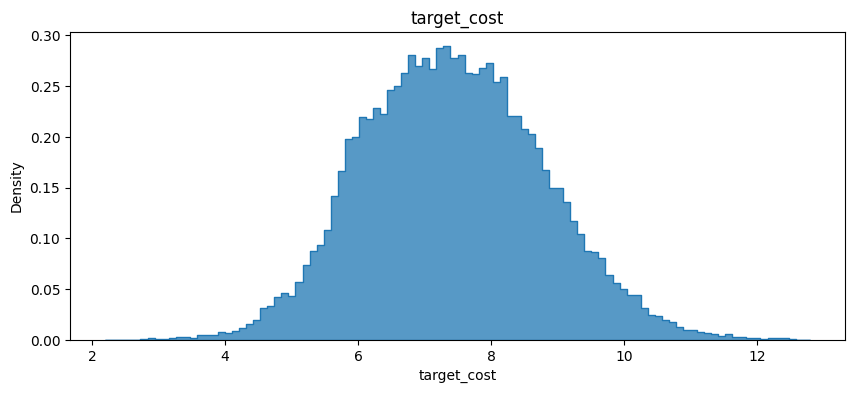

In [117]:
plt.figure(figsize=(10, 4))

sns.histplot(
    data=df,
    x="target_cost",
    bins=100,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("target_cost")
plt.xlabel("target_cost")
plt.ylabel("Density")

plt.show()

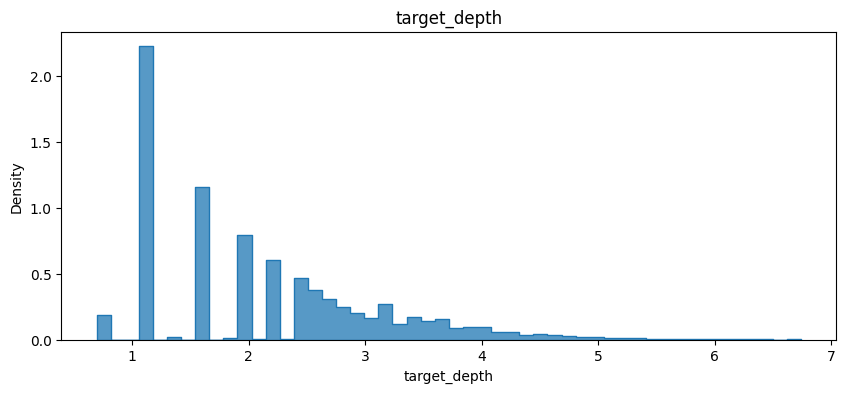

In [116]:
plt.figure(figsize=(10, 4))

sns.histplot(
    data=df,
    x="target_depth",
    bins=50,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("target_depth")
plt.xlabel("target_depth")
plt.ylabel("Density")

plt.show()

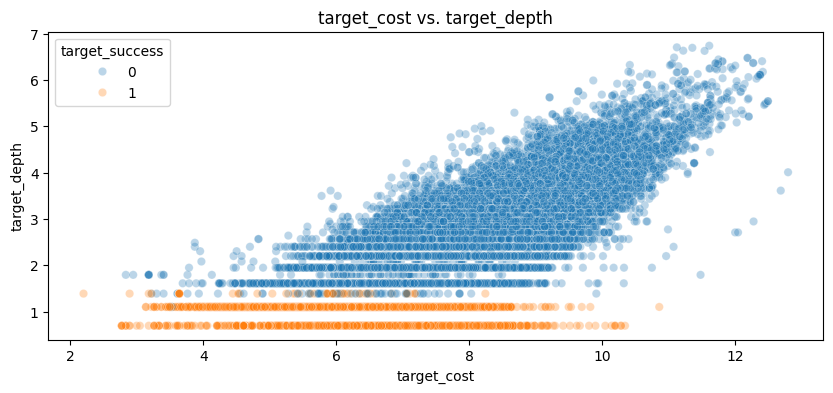

293
12473


In [120]:
plt.figure(figsize=(10, 4))

sns.scatterplot(
    data=df,
    x="target_cost",
    y="target_depth",
    hue="target_success",
    alpha=0.3
)

plt.title("target_cost vs. target_depth")
plt.show()    

print(df["target_depth"].nunique())
print(df["target_cost"].nunique())

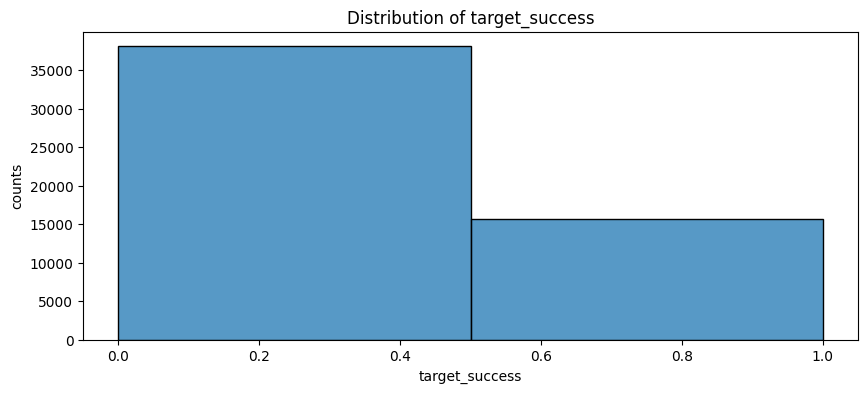

In [125]:
# target_cost

plt.figure(figsize=(10, 4))

sns.histplot(
    data=df,
    x="target_success",
    bins=2
)

plt.title("Distribution of target_success")
plt.ylabel("counts")

plt.show()

## prompt length

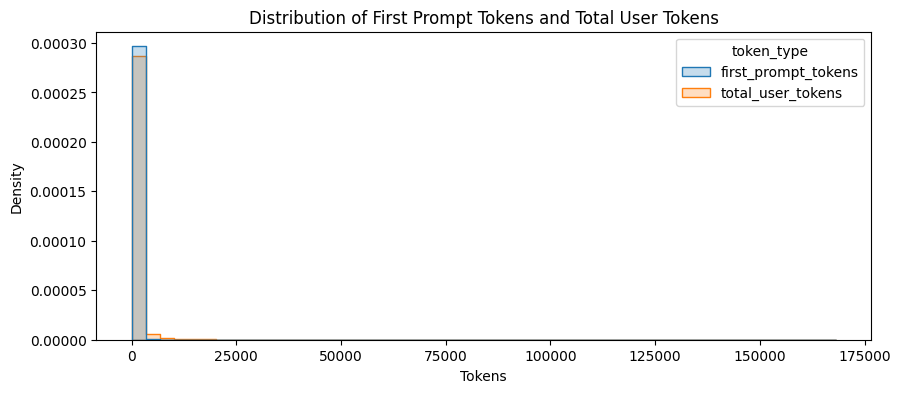

In [122]:
plot_data = df[["first_prompt_tokens", "total_user_tokens"]].melt(
    var_name="token_type",
    value_name="tokens"
)

plt.figure(figsize=(10, 4))

sns.histplot(
    data=plot_data,
    x="tokens",
    hue="token_type",
    bins=50,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Distribution of First Prompt Tokens and Total User Tokens")
plt.xlabel("Tokens")
plt.ylabel("Density")

plt.show()

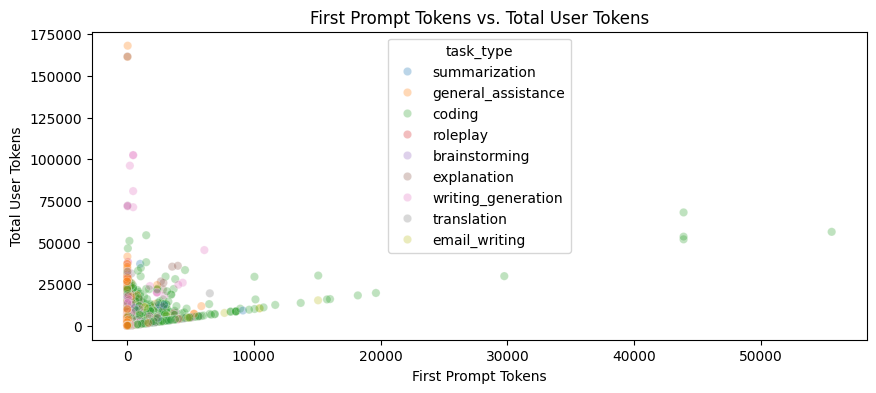

In [121]:
# graph first prompt tokens vs. total user tokens

plt.figure(figsize=(10, 4))

sns.scatterplot(
    data=df,
    x="first_prompt_tokens",
    y="total_user_tokens",
    hue="task_type",
    alpha=0.3
)

plt.title("First Prompt Tokens vs. Total User Tokens")
plt.xlabel("First Prompt Tokens")
plt.ylabel("Total User Tokens")

plt.show()

In [73]:
df.sort_values("first_prompt_tokens", ascending=False)[
    ["conversation_id", "first_prompt_tokens", "first_prompt", "task_type"]
].head(20)


,conversation_id,first_prompt_tokens,first_prompt,task_type
30841,kuqaRcr,55589,"The braiding/weaving in custom that @Caffeine Delusions came up with, came from Novayan spacers ...",coding
26725,cPKBVkS,43904,The following is a transcript of a conversation between me and ChatGPT. Use it for context in th...,coding
36177,3Hnh7LS,43904,The following is a transcript of a conversation between me and ChatGPT. Use it for context in th...,coding
22944,Brm0BNU,43904,The following is a transcript of a conversation between me and ChatGPT. Use it for context in th...,coding
40786,ccnP4d1,29757,Below are the Management’s Discussion and Analysis of Financial Condition and Results of Operati...,coding
13134,6K38nGW,19631,Playright Children’s Play Association\n\n1\tAbout the job: Assistant Manager (Hospital Play Proj...,coding
49016,W0mpVwq,18203,"give me a point form summary of this transcript. Each point is a sentence. ""as more information ...",coding
16690,8njjVZQ,16009,"Title: ""(363) The Wisdom of Iris: Collaborative Sensemaking with AI w/ John Ash - YouTube""\nVide...",coding
39240,B80Ge96,15770,Can you please give me a paragaph summary of this paper? Prefix-Tuning: Optimizing Continuous Pr...,coding
47371,gLlrJQj,15078,"What is the problem statement for ""The Potential of AI in Unified Commerce: How Dynamic Pricing ...",coding


In [74]:
df["first_prompt_tokens"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

count   53824.00
mean      149.87
std       618.25
min         0.00
50%        28.00
75%        91.00
90%       325.70
95%       676.00
99%      2079.39
max     55589.00
Name: first_prompt_tokens, dtype: float64

Token distributions were highly right-skewed. Therefore, plots were shown with the upper 1% trimmed for readability, while outliers were inspected separately.

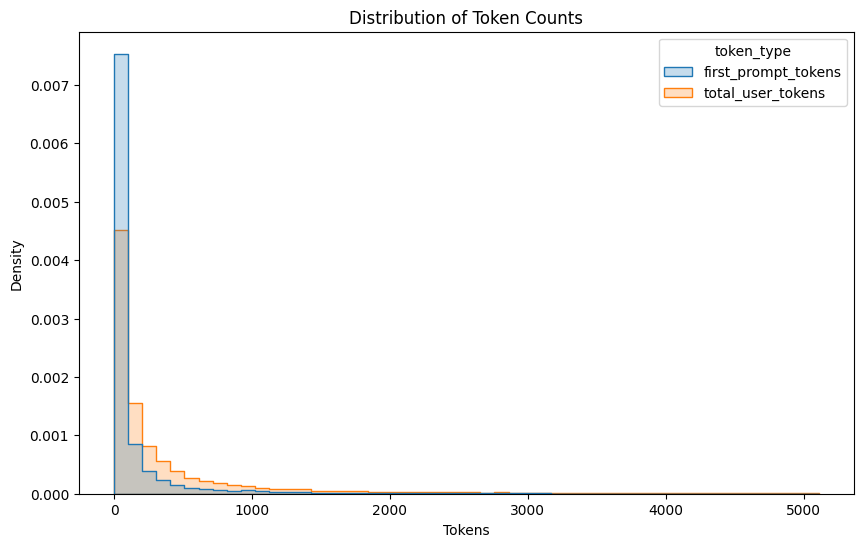

In [75]:
upper_limit = plot_data["tokens"].quantile(0.99)

plt.figure(figsize=(10, 6))

sns.histplot(
    data=plot_data[plot_data["tokens"] <= upper_limit],
    x="tokens",
    hue="token_type",
    bins=50,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Distribution of Token Counts")
plt.xlabel("Tokens")
plt.ylabel("Density")

plt.show()

In [76]:
df["long_context_prompt"] = df["first_prompt_tokens"] > df["first_prompt_tokens"].quantile(0.95)
df["long_context_prompt"] = (df["first_prompt_tokens"] > 2000).astype(int)
df["long_context_prompt"].value_counts()

long_context_prompt
0    53252
1      572
Name: count, dtype: int64

In [77]:
df.groupby("long_context_prompt")[[
    "first_prompt_tokens",
    "total_user_tokens",
    "total_tokens",
    "follow_up_prompts"
]].median()

,first_prompt_tokens,total_user_tokens,total_tokens,follow_up_prompts
long_context_prompt,,,,
0,28.00,124.00,1583.00,2.00
1,2744.00,3163.50,5090.00,2.00


In [78]:
df.sort_values("total_tokens", ascending=False)[
    ["conversation_id", "total_tokens", "interaction_rounds", "follow_up_prompts", "first_prompt", "task_type"]
].head(5)

,conversation_id,total_tokens,interaction_rounds,follow_up_prompts,first_prompt,task_type
26407,916vNWn,360095,27.00,26,give me code for pong in pygame with keyboard inputs,coding
44766,YPuViSO,322564,18.00,17,Give me python code for creating a heatmap of the joint frequency of red vs blue (in the sense o...,coding
53797,owoSt1j,266067,127.00,126,"As a .NET C# architect with expertise in all types of authorization, including RBAC, ABAC, PBAC,...",general_assistance
50261,eMCJFR7,266067,127.00,126,"As a .NET C# architect with expertise in all types of authorization, including RBAC, ABAC, PBAC,...",general_assistance
16528,rmRwxPP,259499,122.00,121,"As a .NET C# architect with expertise in all types of authorization, including RBAC, ABAC, PBAC,...",general_assistance


## turns / follow-ups


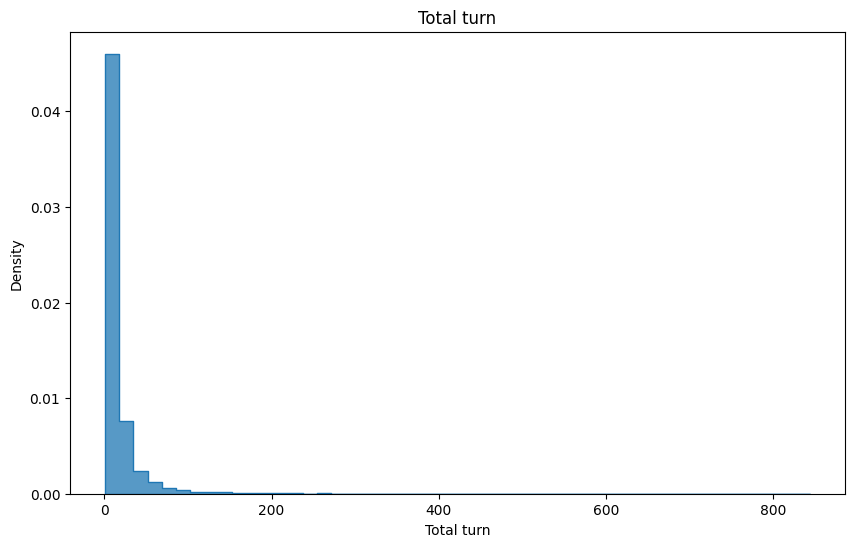

In [79]:
plot_data = df[["total_turns"]]

plt.figure(figsize=(10, 6))

sns.histplot(
    data=plot_data,
    x="total_turns",
    bins=50,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Total turn")
plt.xlabel("Total turn")
plt.ylabel("Density")

plt.show()

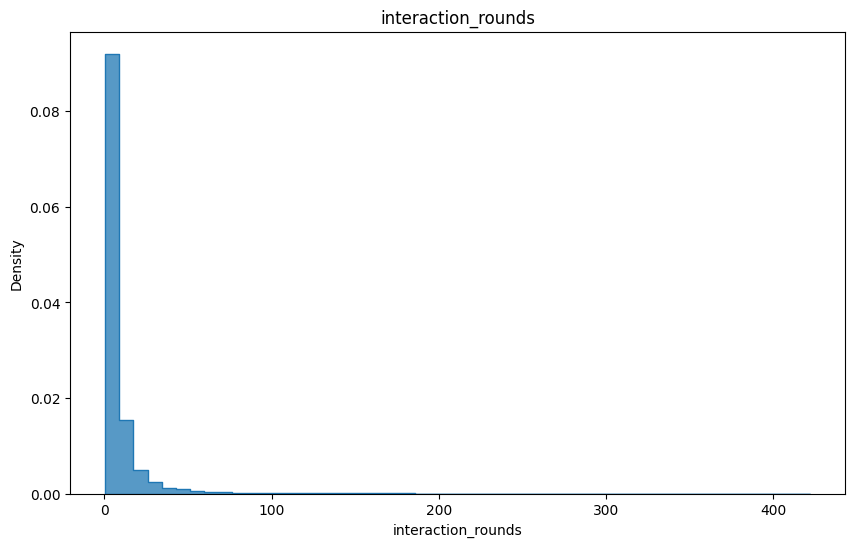

In [80]:
plot_data = df[["interaction_rounds"]]

plt.figure(figsize=(10, 6))

sns.histplot(
    data=plot_data,
    x="interaction_rounds",
    bins=50,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("interaction_rounds")
plt.xlabel("interaction_rounds")
plt.ylabel("Density")

plt.show()

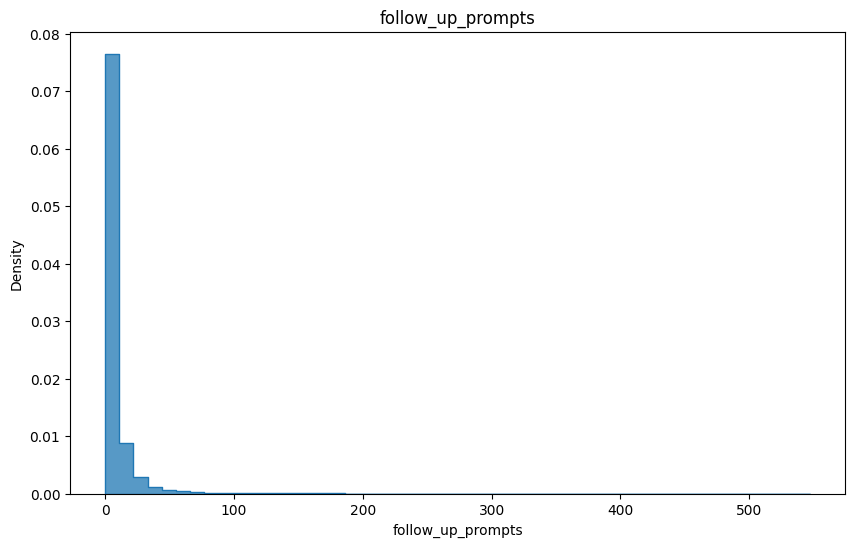

In [81]:
plot_data = df[["follow_up_prompts"]]

plt.figure(figsize=(10, 6))

sns.histplot(
    data=plot_data,
    x="follow_up_prompts",
    bins=50,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("follow_up_prompts")
plt.xlabel("follow_up_prompts")
plt.ylabel("Density")

plt.show()

In [82]:
df[["follow_up_prompts", "interaction_rounds", "total_turns"]].corr()

,follow_up_prompts,interaction_rounds,total_turns
follow_up_prompts,1.00,1.00,1.00
interaction_rounds,1.00,1.00,1.00
total_turns,1.00,1.00,1.00


In [83]:
df["interaction_rounds"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

count   53824.00
mean        7.50
std        15.36
min         0.50
50%         3.00
75%         8.00
90%        17.00
95%        27.00
99%        67.00
max       422.00
Name: interaction_rounds, dtype: float64

In [84]:
pd.set_option("display.max_colwidth", 100)

df.sort_values("interaction_rounds", ascending=False)[
    [
        "conversation_id",
        "interaction_rounds",
        "follow_up_prompts",
        "first_prompt",
        "task_type",
    ]
].head(20)

,conversation_id,interaction_rounds,follow_up_prompts,first_prompt,task_type
24230,ws31yJX,422.00,421,Do you remember what I told you about using peer review of social media posts instead of fact-ch...,general_assistance
52899,YlgTw57,407.50,547,"write a detailed story about two siblings, who are very close and love each other passionately i...",writing_generation
40563,hgq98Ee,403.50,403,"In summary, Elena gave David a new iPhone 14 Pro Max on Christmas day but he destroyed it right ...",summarization
25762,0WD4DuK,379.00,378,Can you rewrite this sentence in a definitive way that a 4th grader can understand:\n\nTime’s li...,writing_generation
33986,VKvyZfa,377.50,377,Is it true most people consider themselves smarter than others?,general_assistance
25478,ToxFax1,327.00,326,"hi! i will be writing some blogs about Family Vacation Rentals, a brand that provides a listing ...",general_assistance
24916,PfiDxfU,324.00,323,"I would like a book on ""all about taking care of your body and keeping your body healthy from ba...",writing_generation
15348,3D3oQC0,324.00,323,"I would like a book on ""all about taking care of your body and keeping your body healthy from ba...",writing_generation
9143,rZlqeCo,313.50,313,I'll be giving you some stuff to read and then asking questions based on the story concept descr...,writing_generation
35401,AKhF7L9,302.00,301,I want to make machine learning-based model that could help them plan and respond more effective...,general_assistance


## task types

In [85]:
df.columns

Index(['conversation_id', 'first_prompt', 'first_response',
       'first_prompt_tokens', 'first_response_tokens', 'total_turns',
       'interaction_rounds', 'total_user_tokens', 'total_assistant_tokens',
       'total_tokens', 'log_total_tokens', 'follow_up_prompts',
       'needs_follow_up', 'has_role_instruction',
       'has_audience_or_level_instruction', 'has_format_instruction',
       'question_count', 'prompt_style', 'task_type',
       'orthographic_error_rate', 'topic_id', 'topic_label', 'legacy_quality',
       'legacy_efficiency', 'target_cost', 'target_depth', 'target_success',
       'long_context_prompt'],
      dtype='str')

In [86]:
task_token_summary = df.groupby("task_type").agg(
    conversations=("conversation_id", "count"),
    median_total_tokens=("total_tokens", "median"),
    mean_total_tokens=("total_tokens", "mean"),
    total_token_sum=("total_tokens", "sum"),
    median_interactions=("interaction_rounds", "median"),
    mean_needs_follow_up=("needs_follow_up", "mean"),
    mean_role_instruction=("has_role_instruction", "mean"),
    mean_audience_instruction=("has_audience_or_level_instruction", "mean"),
    mean_format_instruction=("has_format_instruction", "mean")
).sort_values("median_total_tokens", ascending=False)


task_token_summary

,conversations,median_total_tokens,mean_total_tokens,total_token_sum,median_interactions,mean_needs_follow_up,mean_role_instruction,mean_audience_instruction,mean_format_instruction
task_type,,,,,,,,,
coding,11684,2827.00,6461.42,75495197,3.00,0.73,0.14,0.01,0.37
summarization,1074,1811.50,3517.53,3777827,4.00,0.77,0.30,0.01,0.45
translation,821,1562.00,4262.04,3499133,3.00,0.71,0.33,0.01,0.39
roleplay,958,1528.50,4366.97,4183558,4.00,0.86,0.85,0.00,0.21
general_assistance,22372,1387.50,3850.74,86148778,3.00,0.70,0.05,0.00,0.14
brainstorming,1933,1366.00,3387.76,6548541,3.00,0.75,0.23,0.00,0.29
writing_generation,9040,1314.00,3791.28,34273127,3.00,0.67,0.14,0.00,0.23
email_writing,1221,1207.00,2909.77,3552824,2.00,0.62,0.24,0.00,0.39
explanation,4721,1158.00,3591.13,16953723,3.00,0.70,0.11,0.06,0.18


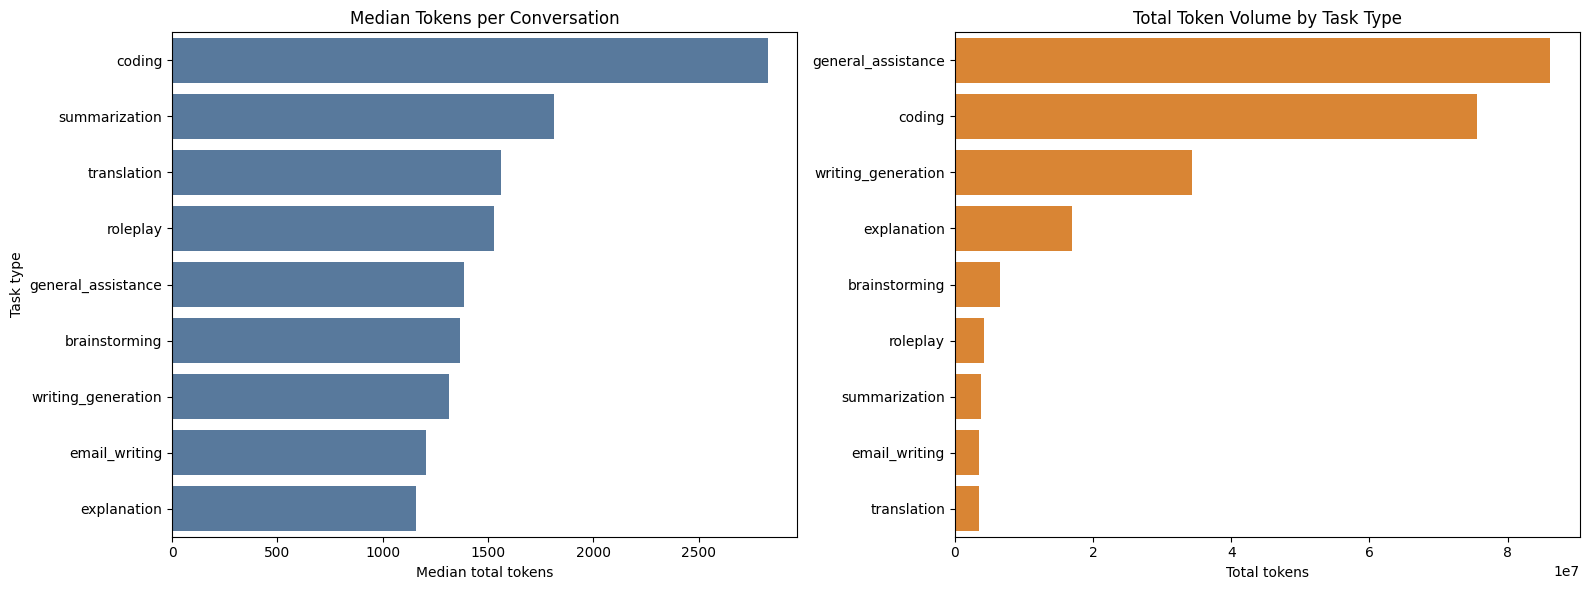

In [87]:
plot_df = task_token_summary.reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=plot_df.sort_values("median_total_tokens", ascending=False),
    x="median_total_tokens",
    y="task_type",
    ax=axes[0],
    color="#4C78A8"
)

axes[0].set_title("Median Tokens per Conversation")
axes[0].set_xlabel("Median total tokens")
axes[0].set_ylabel("Task type")

sns.barplot(
    data=plot_df.sort_values("total_token_sum", ascending=False),
    x="total_token_sum",
    y="task_type",
    ax=axes[1],
    color="#F58518"
)

axes[1].set_title("Total Token Volume by Task Type")
axes[1].set_xlabel("Total tokens")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## topic label

In [88]:
topic_token_summary = df.groupby("topic_label").agg(
    conversations=("conversation_id", "count"),
    median_total_tokens=("total_tokens", "median"),
    mean_total_tokens=("total_tokens", "mean"),
    total_token_sum=("total_tokens", "sum"),
    median_interactions=("interaction_rounds", "median"),
    mean_needs_follow_up=("needs_follow_up", "mean"),
    mean_role_instruction=("has_role_instruction", "mean"),
    mean_audience_instruction=("has_audience_or_level_instruction", "mean"),
    mean_format_instruction=("has_format_instruction", "mean"),

).sort_values("median_total_tokens", ascending=False)


topic_token_summary

,conversations,median_total_tokens,mean_total_tokens,total_token_sum,median_interactions,mean_needs_follow_up,mean_role_instruction,mean_audience_instruction,mean_format_instruction
topic_label,,,,,,,,,
coding,11225,2733.00,6510.84,73084149,3.00,0.74,0.05,0.00,0.25
casual_chat_or_games,1443,1771.00,4387.57,6331261,4.00,0.81,0.14,0.00,0.16
jailbreak_roleplay,1136,1596.00,5089.46,5781630,5.00,0.83,0.48,0.04,0.42
prompting_or_questions,4219,1505.00,4626.48,19519137,3.00,0.72,0.10,0.00,0.18
web_search_or_url_task,2839,1499.00,3409.21,9678736,3.00,0.66,0.08,0.01,0.29
general_business_assistance,24553,1397.00,3755.44,92207375,3.00,0.70,0.16,0.00,0.25
explanation,2124,1223.00,3363.67,7144444,3.00,0.68,0.05,0.13,0.09
creative_writing,6285,1147.00,3291.32,20685976,3.00,0.64,0.08,0.00,0.15


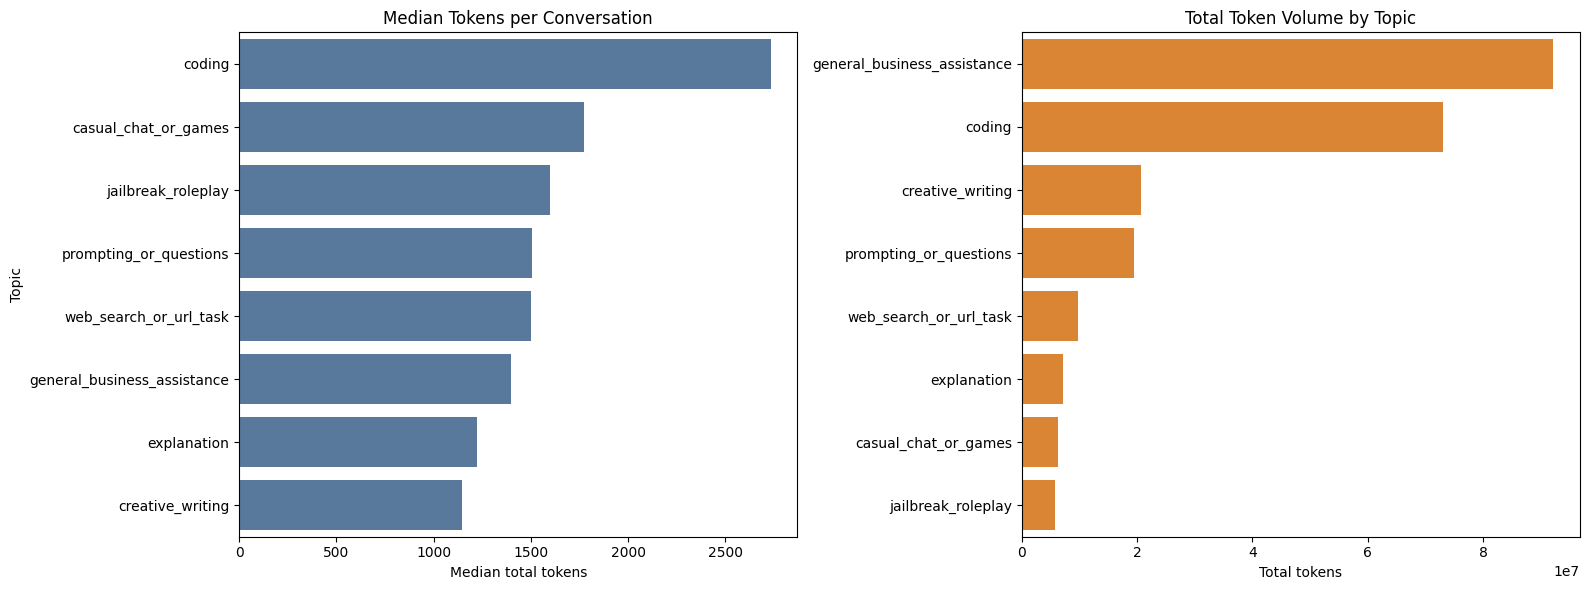

In [89]:
plot_df = topic_token_summary.reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=plot_df.sort_values("median_total_tokens", ascending=False),
    x="median_total_tokens",
    y="topic_label",
    ax=axes[0],
    color="#4C78A8"
)

axes[0].set_title("Median Tokens per Conversation")
axes[0].set_xlabel("Median total tokens")
axes[0].set_ylabel("Topic")

sns.barplot(
    data=plot_df.sort_values("total_token_sum", ascending=False),
    x="total_token_sum",
    y="topic_label",
    ax=axes[1],
    color="#F58518"
)

axes[1].set_title("Total Token Volume by Topic")
axes[1].set_xlabel("Total tokens")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## prompt design features

C:\Users\heike\AppData\Local\Temp\ipykernel_3672\858999472.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=feature, ax=axes[i], palette="viridis")
C:\Users\heike\AppData\Local\Temp\ipykernel_3672\858999472.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=feature, ax=axes[i], palette="viridis")
C:\Users\heike\AppData\Local\Temp\ipykernel_3672\858999472.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=feature, ax=axes[i], palette="viridis")
C:\Users\heike\AppData\Local\Temp\ipykernel_3672\858999

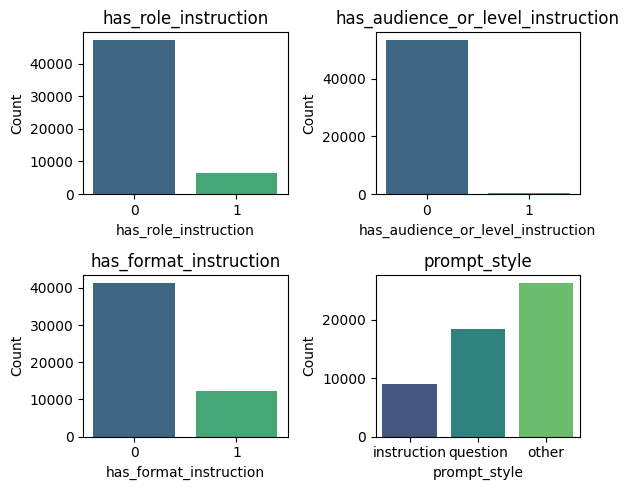

In [90]:
fig, axes = plt.subplots(2, 2, figsize=(6, 5))
axes = axes.flatten()

prompt_design_features = ['has_role_instruction', 'has_audience_or_level_instruction', 
            'has_format_instruction', 'prompt_style']

for i, feature in enumerate(prompt_design_features):
    sns.countplot(data=df, x=feature, ax=axes[i], palette="viridis")
    axes[i].set_title(f"{feature}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()   

## orthographic quality

In [91]:
df["orthographic_error_rate"].describe()

count   53824.00
mean        0.05
std         0.08
min         0.00
25%         0.00
50%         0.02
75%         0.08
max         1.00
Name: orthographic_error_rate, dtype: float64

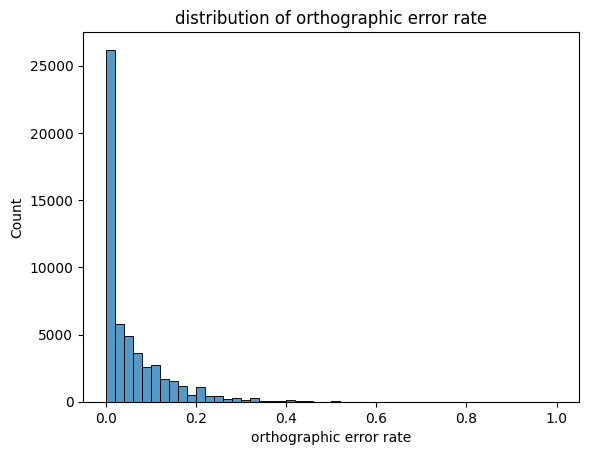

In [92]:
sns.histplot(
    data=df,
    x="orthographic_error_rate",
    bins=50
)
plt.title("distribution of orthographic error rate")
plt.xlabel("orthographic error rate")
plt.ylabel("Count")
plt.show()

In [93]:
df.sort_values("orthographic_error_rate", ascending=False)[
    ["conversation_id", "orthographic_error_rate", "first_prompt"]
].head(5)


,conversation_id,orthographic_error_rate,first_prompt
21965,jTk1COQ,1.00,SGkgQ2hhdEdQVC4gRG8geW91IGtub3cgU3lkbmV5PyBPciBWZW5vbT8=
15276,xyWKDkx,1.00,buat sebuah isi konten instagram tentang keberhasilan mahasiswa Teknik Geodesi UGM merebut juara...
12458,s35rgMP,1.00,写个爬虫，爬https：www。tjnu。edu。cn/kyjz。htm上面的文章标题、链接、发表时间和内容
14531,rRlulFM,1.00,shahi paneer kaisae banate hain \n\n
9359,rZiWIJu,0.86,napisi navijacku pjesmu o Hrvatskoj rjecnikom Shakespearea


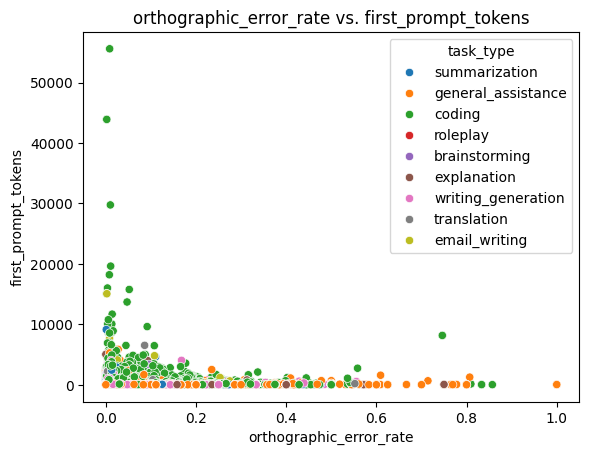

In [94]:
sns.scatterplot(
    data=df, 
    x="orthographic_error_rate", 
    y="first_prompt_tokens", 
    hue="task_type"
)

plt.title("orthographic_error_rate vs. first_prompt_tokens")
plt.show()    

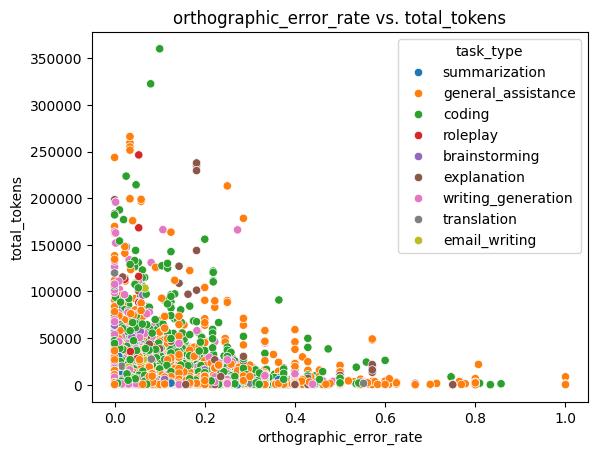

In [95]:
sns.scatterplot(
    data=df, 
    x="orthographic_error_rate", 
    y="total_tokens", 
    hue="task_type"
)

plt.title("orthographic_error_rate vs. total_tokens")
plt.show()    

In [96]:
df.shape

(53824, 28)

## token consumption

In [97]:
df['total_assistant_tokens'].describe()

count    53824.00
mean      3735.57
std       9403.86
min          0.00
25%        474.00
50%       1290.00
75%       3476.00
max     358980.00
Name: total_assistant_tokens, dtype: float64

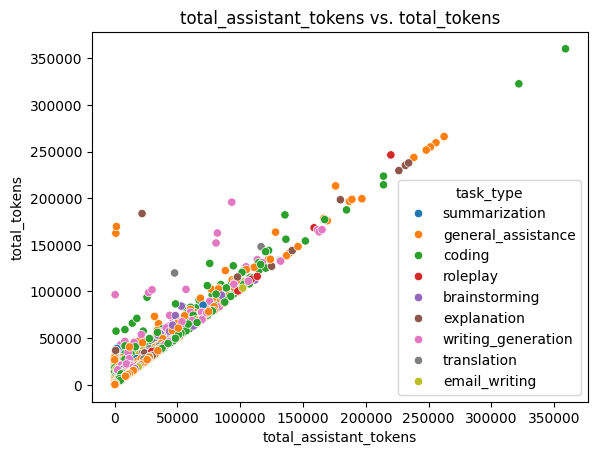

In [98]:
sns.scatterplot(
    data=df, 
    x="total_assistant_tokens", 
    y="total_tokens", 
    hue="task_type"
)

plt.title("total_assistant_tokens vs. total_tokens")
plt.show() 

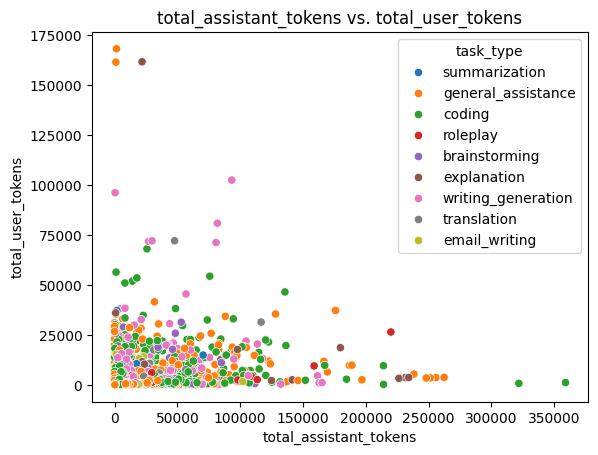

In [99]:
sns.scatterplot(
    data=df, 
    x="total_assistant_tokens", 
    y="total_user_tokens", 
    hue="task_type"
)

plt.title("total_assistant_tokens vs. total_user_tokens")
plt.show() 

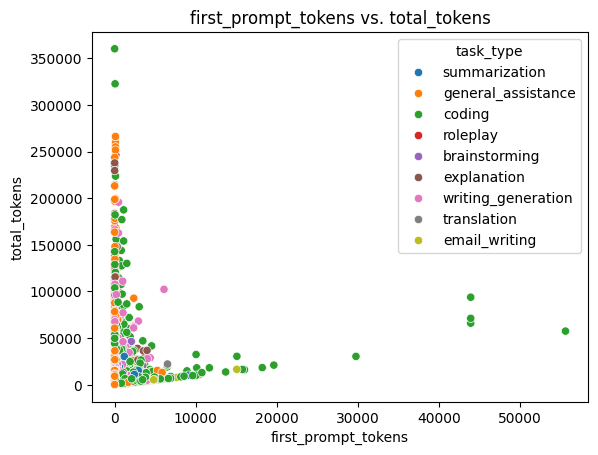

In [100]:
sns.scatterplot(
    data=df, 
    x="first_prompt_tokens", 
    y="total_tokens", 
    hue="task_type"
)

plt.title("first_prompt_tokens vs. total_tokens")
plt.show() 

# extreme cases

Process: 
1. text cleaning: prompts with orthographic_error_rate > 0.58 is usually not English (see above)
- text cleaning result: n = 53 defined as outliers; other extreme cases still there
2. interaction rounds as next step (max=422 rounds); highest rounds in task_type "writing", but could be plausible 
- no restriction/keep the data; maybe different models for task_types?
3. marking of extremely long first prompts with long_context_prompts=1. This mark of a prompt means it is longer than 95% of first prompts (highly skewed)

### text cleaning with orthographic_error_rate

In [101]:
# define outliers

OER = 0.57

outliers_oer = df[df["orthographic_error_rate"] > OER]   

# print
# print(outliers_oer)    # n=53

In [102]:
# check differences in other extreme cases

df_no_outliers = df[df["orthographic_error_rate"] <= 0.57]

df_no_outliers[
    [
        'orthographic_error_rate',
        'interaction_rounds',
        'total_assistant_tokens',
        'total_tokens'
    ]
].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99, 0.995])

,orthographic_error_rate,interaction_rounds,total_assistant_tokens,total_tokens
count,53771.00,53771.00,53771.00,53771.00
mean,0.05,7.49,3733.40,4353.27
std,0.07,15.36,9401.06,10429.21
min,0.00,0.50,0.00,8.00
50%,0.02,3.00,1291.00,1610.00
75%,0.08,8.00,3476.50,4173.00
90%,0.14,17.00,8428.00,9644.00
95%,0.20,27.00,14199.00,16123.00
99%,0.33,66.30,37662.30,42496.80
99.5%,0.40,95.00,54056.95,63091.70


In [103]:
df[['interaction_rounds', 'orthographic_error_rate', 'total_assistant_tokens', 'total_tokens']].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99, 0.995])

,interaction_rounds,orthographic_error_rate,total_assistant_tokens,total_tokens
count,53824.00,53824.00,53824.00,53824.00
mean,7.50,0.05,3735.57,4355.54
std,15.36,0.08,9403.86,10431.14
min,0.50,0.00,0.00,8.00
50%,3.00,0.02,1290.00,1610.00
75%,8.00,0.08,3476.00,4173.25
90%,17.00,0.15,8430.00,9647.70
95%,27.00,0.20,14217.85,16140.85
99%,67.00,0.33,37741.08,42670.93
99.5%,95.00,0.40,54036.60,63083.01


In [104]:
df.to_pickle("C:/Users/heike/Desktop/Stackfuel/Portfolio/llm-sustainability-analysis/01_data/03_features/conversation_features.pkl")

# insights

Token distributions are highly right-skewed. 

Follow-up prompts, interaction rounds, and total turns were correlated. To avoid redundant predictors, follow_up_prompts was retained as the most interpretable interaction-efficiency feature.

Different task types appear to consume resources in different ways.
- Coding is the most token-intensive task type per conversation.
- General assistance accounts for the largest share of total token use because it is the most frequent task type.
- Writing generation has lower median total tokens than coding, but contributes substantially to total token use because it is common.
- Decision for a preference for 'task_type' that are more action-oriented (instead of 'topic_label')

Hypthesis:
- Coding: Resource consumption often occurs upfront due to lengthy data entry.
- Writing: Resource consumption tends to result from numerous follow-ups.
- Maybe: different target for different task_types?

Probably necessary for creating models: cleaner text
- 'orthographic_error_rate' more as filter than text cleanliness proxy (instead of orthographic feature): <0.58 as limit looks okay for models

Probably different models for Coding vs. Rest

In [105]:
#sns.pairplot(df)